# 2 · The landscape

We simulated **every** feasible configuration of the small space ahead of time. That oracle is loaded here. With it, three questions have exact answers:

1. How is cost distributed? 
2. Which parameters matter?
3. What do the good configurations have in common?

In [17]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dse
import dse.plots as plots
from dse import DATA, WORK

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

In [18]:
import json

mlir = DATA / "small" / "gemv.mlir"
oracle = dse.load_pool(DATA / "small" / "pool.csv")
space = dse.load_space(DATA / "small" / "space.json")

best = oracle["cost"].min()
median = oracle["cost"].median()

guess_file = WORK / "my_guess.json"
if guess_file.exists():
    my = json.loads(guess_file.read_text())
    my_cost = my["cost_ms"]
else:
    # No guess from notebook 1: take the median configuration as a stand-in.
    my_cost = median
    print("no guess saved by notebook 1; using the median as yours")

print(f"{len(oracle)} feasible configurations")
print(f"best   {best:7.2f} ms")
print(f"median {median:7.2f} ms")
print(f"yours  {my_cost:7.2f} ms  →  rank {dse.rank_of(my_cost, oracle)} of {len(oracle)}, "
      f"better than {100 - dse.percentile_of(my_cost, oracle):.0f} % of the space")

3234 feasible configurations
best      1.60 ms
median    9.50 ms
yours     7.93 ms  →  rank 145 of 3234, better than 96 % of the space


## How cost is distributed

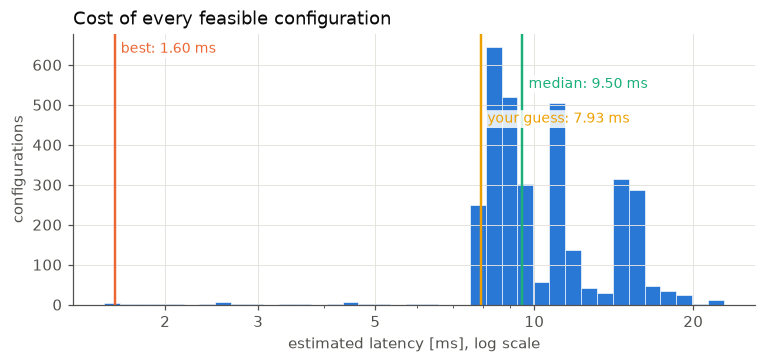

within 1.1× of the best:    6 configurations
within 1.5× of the best:   11 configurations
within 2× of the best:   19 configurations
within 3× of the best:   30 configurations


In [19]:
ax = plots.cost_histogram(oracle, {"best": best, "median": median, "your guess": my_cost})
plt.show()

for f in (1.1, 1.5, 2, 3):
    print(f"within {f}× of the best: {(oracle['cost'] <= f * best).sum():4d} configurations")

The bulk sits between 8 and 12 ms. The best configurations are **five times**
faster than the median and there are only a handful of them: a needle, not a
hill. Any search that samples uniformly is unlikely to land on one.

## Which parameters matter

For each parameter, the best and the median cost at each of its values. A
parameter whose *best* line moves a lot is one the search has to get right.

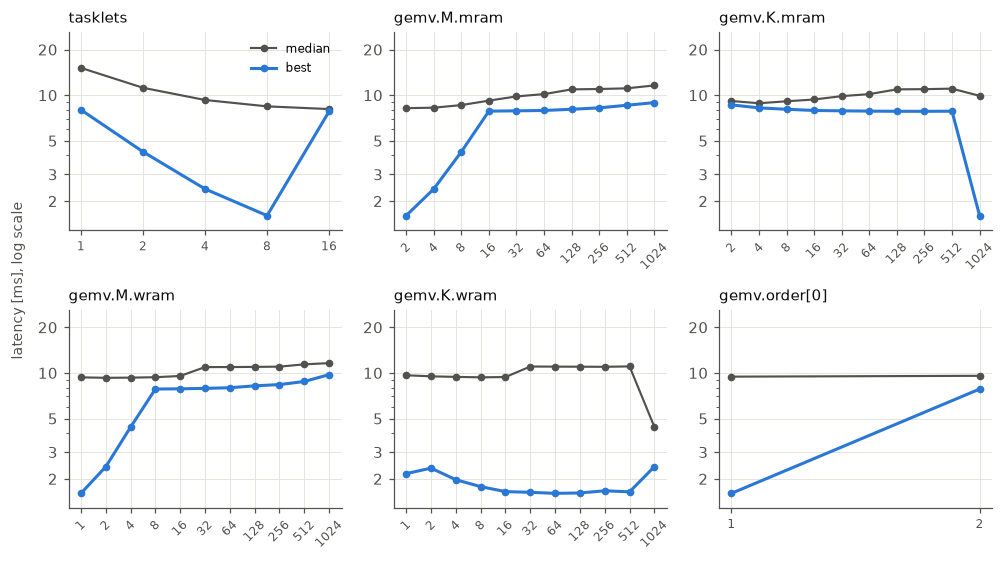

In [20]:
fig = plots.marginals(oracle, ["tasklets", "gemv.M.mram", "gemv.K.mram",
                               "gemv.M.wram", "gemv.K.wram", "gemv.order[0]"])
plt.show()

Two things to notice:

- **`tasklets`** — the best configuration uses 8 of the 16 threads. Using all
  of them is *worse* than using half: the tiles each tasklet can hold shrink,
  and the per-launch overhead grows.
- **`gemv.K.mram`** — only the full extent, 1024, reaches the fast region. That
  is the reduction dimension: splitting it across workers means partial sums
  that have to be combined afterwards.

The WRAM tiles, by contrast, barely move the best line: once the MRAM tiles are
right, the inner tiling is forgiving.

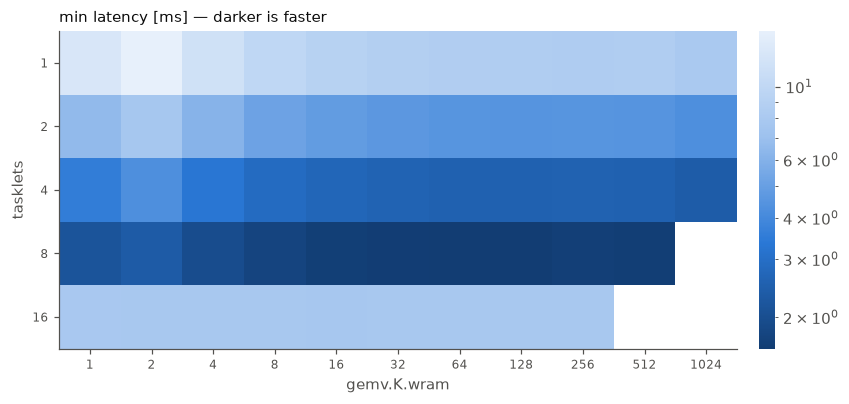

In [21]:
plots.heatmap(oracle, x="gemv.K.wram", y="tasklets")
plt.show()

## What the good configurations have in common

In [22]:
cols = dse.param_columns(oracle) + ["cost"]
oracle.sort_values("cost").head(10)[cols].style.format({"cost": "{:.3f}"}).hide(axis="index")

dpus,tasklets,gemv.M.mram,gemv.M.wram,gemv.K.mram,gemv.K.wram,gemv.order[0],gemv.order[1],cost
64,8,2,1,1024,64,1,2,1.604
64,8,2,1,1024,128,1,2,1.614
64,8,2,1,1024,32,1,2,1.630
64,8,2,1,1024,512,1,2,1.642
64,8,2,1,1024,16,1,2,1.648
64,8,2,1,1024,256,1,2,1.668
64,8,2,1,1024,8,1,2,1.777
64,8,2,1,1024,4,1,2,1.974
64,8,2,1,1024,1,1,2,2.165
64,8,2,1,1024,2,1,2,2.354


The ten best configurations differ in **one** parameter. Everything else —
tasklets, both MRAM tiles, the loop order — is the same. The optimum is not a
point but a short line through a seven-dimensional space, and the whole line
is the same *shape*: distribute M finely across the workers, keep K whole.

## Pinning a hardware knob — live

The hardware parameters and the tiling parameters are not independent. Pin the
number of tasklets and exhaustively search what is left; it is a fifth of the
space and takes about half a minute on one core.

In [23]:
r = dse.exhaustive(mlir, "exhaustive_t8", fixed_tasklets=8)
sub = r.pool()

print(f"{len(sub)} configurations with tasklets = 8, simulated in {r.seconds:.0f} s")
print(f"best in the subspace: {sub['cost'].min():.3f} ms   (whole space: {best:.3f} ms)")

616 configurations with tasklets = 8, simulated in 34 s                                             
best in the subspace: 1.604 ms   (whole space: 1.604 ms)


In [24]:
# The same comparison for tasklets = 16, read off the oracle rather than re-run.
for t in (1, 4, 8, 16):
    part = oracle[oracle["tasklets"] == t]
    print(f"tasklets = {t:2d}: {len(part):4d} configurations, best {part['cost'].min():6.2f} ms")

tasklets =  1:  718 configurations, best   8.01 ms
tasklets =  4:  680 configurations, best   2.41 ms
tasklets =  8:  616 configurations, best   1.60 ms
tasklets = 16:  506 configurations, best   7.83 ms


Fixing a hardware knob to the wrong value caps what any tiling can reach —
with 16 tasklets the best possible configuration is five times slower than
with 8. Whoever decides the hardware parameters has to see the tiling space,
and the other way round.

→ Notebook 3: finding the needle without simulating the haystack.